In [1]:
from src.data_loader import DataManager
import src.analytics as analytics
import src.plotting as pl

In [2]:
data_m = DataManager("../database_2026-03-04")
data_m.load_everything()

In [3]:
close_prices = data_m.close_prices

## Overview of properties

In [4]:
selected = ["S&P 500", "Russell 2000", "EURUSD", "Bitcoin", "Gold"]
returns_sel = returns[selected]
close_prices_sel = close_prices[selected]

In [5]:
returns_sel.describe().loc[["mean", "std", "min", "max"], :].round(3)

,S&P 500,Russell 2000,EURUSD,Bitcoin,Gold
mean,0.000,0.000,0.000,0.001,0.001
std,0.011,0.015,0.005,0.032,0.011
min,-0.059,-0.076,-0.018,-0.143,-0.114
max,0.095,0.087,0.023,0.123,0.061


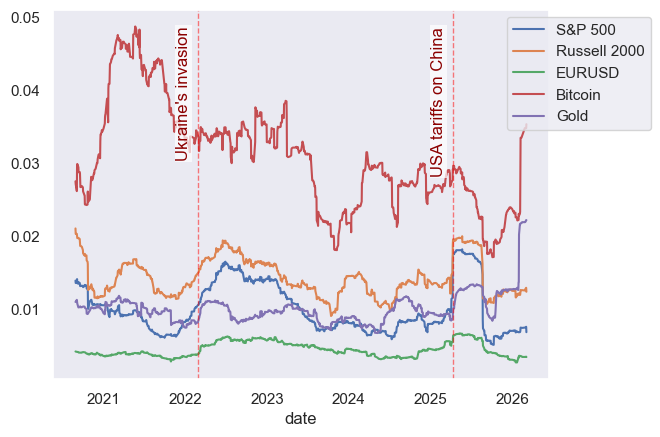

In [6]:
pl.rolling_volatility_plot(returns_sel, window=60)

In [7]:
analytics.longest_drawdown(close_prices_sel)

,asset,start,end,length
0,S&P 500,2000-03-27,2007-05-29,2619
1,Russell 2000,2000-03-10,2004-04-02,1484
2,EURUSD,2008-04-23,2026-03-04,6524
3,Bitcoin,2013-12-05,2017-03-01,1182
4,Gold,2011-08-23,2020-07-23,3257


## Correlations and relationships

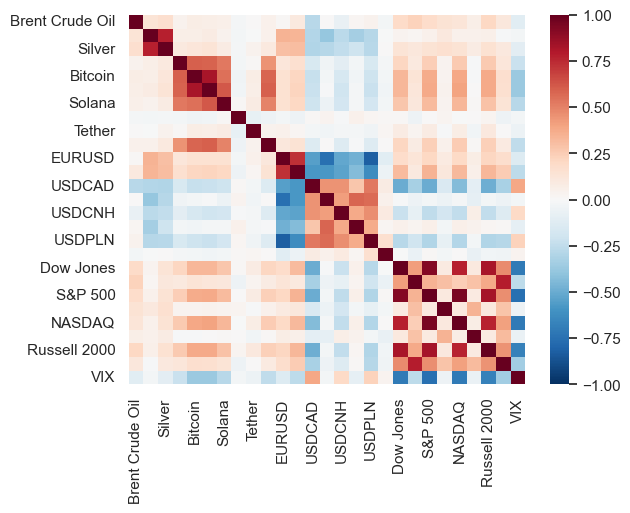

In [8]:
pear_cor, pear_pvals = analytics.correlations(returns, "pearson")
spear_cor, spear_pvals = analytics.correlations(returns, "spearman")
pl.heatmap_corr(pear_cor)

In [9]:
analytics.corr_score(pear_cor, pear_pvals)

S&P 500            8.023281
USDCAD             7.948879
Russell 2000       7.740882
Dow Jones          7.581100
NASDAQ             7.517464
GBPUSD             7.242148
USDPLN             6.983015
EURUSD             6.754333
VIX                6.554241
Ethereum           6.151198
Bitcoin            6.011640
USDCNH             5.779183
EURO STOXX 50      5.585242
Solana             5.045780
FTSE 100           4.816160
Silver             4.540287
Binance Coin       4.400142
XRP                4.239213
USDCHF             4.112556
Gold               3.436240
USDJPY             3.163355
Hang Seng Index    2.365757
Brent Crude Oil    2.278148
Nikkei 225         1.871149
Tether             0.647484
USDRUB             0.601341
USD Coin           0.083835
dtype: float64

In [10]:
analytics.corr_score(spear_cor, spear_pvals)

S&P 500            8.095499
USDCAD             8.042035
Russell 2000       8.008145
GBPUSD             7.723991
NASDAQ             7.583615
Dow Jones          7.489057
USDPLN             7.214311
EURUSD             7.196454
VIX                6.882824
Ethereum           6.720758
Bitcoin            6.569126
USDCNH             6.271613
Binance Coin       5.903617
Solana             5.681995
EURO STOXX 50      5.551855
USDCHF             5.367874
Silver             5.308067
XRP                5.286064
FTSE 100           4.640388
Gold               4.102382
USDJPY             3.260721
Tether             2.379115
Brent Crude Oil    2.238112
Hang Seng Index    2.186818
Nikkei 225         1.809831
USDRUB             1.365414
USD Coin           0.000000
dtype: float64

In [11]:
(pear_cor.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(pear_pvals.loc[selected, selected]), axis=None))

,S&P 500,Russell 2000,EURUSD,Bitcoin,Gold
S&P 500,1.000,0.834,0.207,0.369,0.050
Russell 2000,0.834,1.000,0.216,0.378,0.062
EURUSD,0.207,0.216,1.000,0.155,0.349
Bitcoin,0.369,0.378,0.155,1.000,0.070
Gold,0.050,0.062,0.349,0.070,1.000


In [12]:
reg, reg_pvals = analytics.regression(returns_sel)
(reg.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(reg_pvals.loc[selected, selected]), axis=None))

,S&P 500,Russell 2000,EURUSD,Bitcoin,Gold
S&P 500,1.000,1.152,0.089,1.101,0.052
Russell 2000,0.604,1.000,0.067,0.817,0.046
EURUSD,0.481,0.696,1.000,1.079,0.839
Bitcoin,0.124,0.175,0.022,1.000,0.024
Gold,0.049,0.083,0.146,0.204,1.000


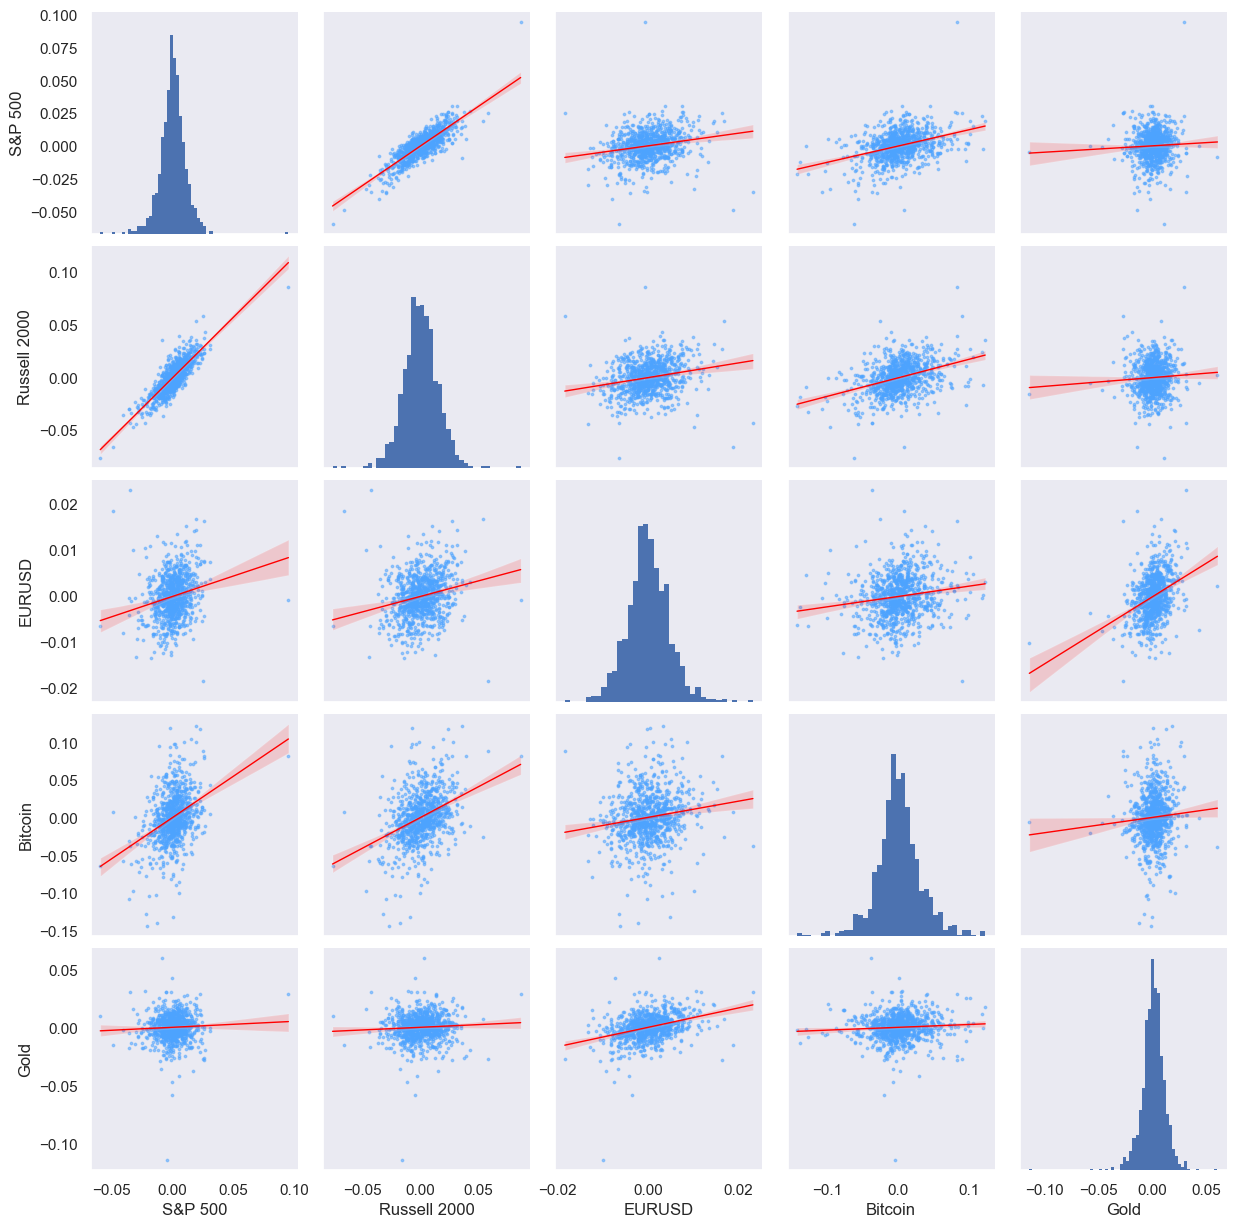

In [13]:
pl.price_change_distributions(returns_sel)